# Estimation of the NMZI model's parameters

In [1]:
import matplotlib.pyplot as plt

import sys
import LOB_data as LOB
import NMZI_parameters as NMZI_p
import pandas as pd

Load files

In [3]:
import pandas as pd
import numpy as np

# === Date Set ===
base_dates = [
    '2025-08-01','2025-08-04','2025-08-05','2025-08-06',
    '2025-08-07','2025-08-08','2025-08-11','2025-08-12',
    '2025-08-13',
    '2025-08-14',
    '2025-08-15',
    '2025-08-18',
    '2025-08-19',
    '2025-08-20',
    '2025-08-21',
    '2025-08-22',
    '2025-08-25',
    '2025-08-26',
    '2025-08-27',
    '2025-08-28',
    '2025-08-29',
    '2025-09-02',
    '2025-09-03',
    '2025-09-04',
    '2025-09-05',
    '2025-09-08',
    '2025-09-09',
    '2025-09-10',
]

symbol = "AMZN"
path = "./Data/AMZN/"

# human-readable labels (NÃO substituir as colunas numéricas!)
type_map = {
    1: "new_limit_order",
    2: "cancel_order",
    3: "delete_order",
    4: "execute_visible",
    5: "execute_hidden",
    6: "auction_trade",
    7: "trading_halt",
}
direction_map = {1: "buy", -1: "sell"}

# horário de corte (em segundos após meia-noite)
START_SEC = 10 * 3600          # 10:00:00
END_SEC   = 15 * 3600 + 30*60  # 15:30:00

all_messages = []
all_orderbooks = []

for base_date_str in base_dates:
    print(f"Processing {base_date_str}...")
    base_date = pd.Timestamp(base_date_str)

    orderbook_file = f"{path}{symbol}_{base_date_str}_34200000_57600000_orderbook_5.csv"
    message_file   = f"{path}{symbol}_{base_date_str}_34200000_57600000_message_5.csv"

    # LOBSTER: tipicamente não tem header
    orderbook = pd.read_csv(orderbook_file, header=None)
    messages  = pd.read_csv(message_file,  header=None, low_memory=False)

    # Drop last column of messages (LOBSTER technical column)
    messages = messages.iloc[:, :-1]

    messages.columns = ['Time', 'Type', 'ID', 'Size', 'Price', 'Direction']

    # infer depth do nome do arquivo
    depth_str = orderbook_file.rsplit('_', 1)[-1].split('.')[0]
    lob_depth = int(depth_str)

    # colunas do book
    ob_columns = []
    for level in range(1, lob_depth + 1):
        ob_columns.extend([
            f'AskPrice_{level}', f'AskSize_{level}',
            f'BidPrice_{level}', f'BidSize_{level}'
        ])
    orderbook.columns = ob_columns

    # normalização de preço
    messages['Price'] = messages['Price'] / 10000.0
    for level in range(1, lob_depth + 1):
        orderbook[f'AskPrice_{level}'] = orderbook[f'AskPrice_{level}'] / 10000.0
        orderbook[f'BidPrice_{level}'] = orderbook[f'BidPrice_{level}'] / 10000.0

    # (opcional) se a primeira linha for lixo no seu dataset, aplique o drop ALINHADO
    # mas o padrão certo é NÃO dropar; deixe comentado.
    # messages  = messages.iloc[1:].reset_index(drop=True)
    # orderbook = orderbook.iloc[1:].reset_index(drop=True)

    # filtro horário usando Time em segundos (mantém schema!)
    t = pd.to_numeric(messages['Time'], errors='coerce')
    mask = (t >= START_SEC) & (t <= END_SEC)
    messages = messages.loc[mask].reset_index(drop=True)
    orderbook = orderbook.loc[mask].reset_index(drop=True)

    # extras “human friendly” (não atrapalham o cleaning)
    messages['TimeDatetime']    = base_date + pd.to_timedelta(messages['Time'], unit='s')
    messages['TypeLabel']       = messages['Type'].map(type_map)
    messages['DirectionLabel']  = messages['Direction'].map(direction_map)

    all_messages.append(messages)
    all_orderbooks.append(orderbook)

messages_all = pd.concat(all_messages, ignore_index=True)
orderbook_all = pd.concat(all_orderbooks, ignore_index=True)

print("✅ Files Concatenate with Success!")
print(f"Total Number of LOB events: {len(messages_all):,}")
print("Columns:", messages_all.columns.tolist())


Processing 2025-08-01...
Processing 2025-08-04...
Processing 2025-08-05...
Processing 2025-08-06...
Processing 2025-08-07...
Processing 2025-08-08...
Processing 2025-08-11...
Processing 2025-08-12...
Processing 2025-08-13...
Processing 2025-08-14...
Processing 2025-08-15...
Processing 2025-08-18...
Processing 2025-08-19...
Processing 2025-08-20...
Processing 2025-08-21...
Processing 2025-08-22...
Processing 2025-08-25...
Processing 2025-08-26...
Processing 2025-08-27...
Processing 2025-08-28...
Processing 2025-08-29...
Processing 2025-09-02...
Processing 2025-09-03...
Processing 2025-09-04...
Processing 2025-09-05...
Processing 2025-09-08...
Processing 2025-09-09...
Processing 2025-09-10...
✅ Files Concatenate with Success!
Total Number of LOB events: 21,164,352
Columns: ['Time', 'Type', 'ID', 'Size', 'Price', 'Direction', 'TimeDatetime', 'TypeLabel', 'DirectionLabel']


In [6]:
path_folder = './'
path_message_file = 'Data/AMZN/AMZN_2025-08-01_34200000_57600000_message_5.csv'
path_ob_file = 'Data/AMZN/AMZN_2025-08-01_34200000_57600000_orderbook_5.csv'

tick_size = 0.01

data = LOB.LOB_data(path_folder, path_message_file, path_ob_file, tick_size)
data.load_and_clean_LOB_data(message_file_with_extra_column=True)
data.cut_before_and_after_LOB_data(60, 60)


Loading message and order book file ...


/Users/felipemoret/Desktop/PhD_Exams/MM_DRL/LOB_data_2.py:125: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  self.message_file = pd.read_csv(self.path_folder + self.label_message_file, header=None)


Check shapes of the new files: True
Data set length: 1904239

Message file first lines
           Time  Type        ID  Size   Price  Direction  DayID       TimeAbs
0  34200.000535     4  62255753    49  217.08         -1      0  34200.000535
1  34200.000699     3  62014909   267  217.24         -1      0  34200.000699
2  34200.001097     1  62288141   106  217.05          1      0  34200.001097
3  34200.001226     3  62286649   106  217.10         -1      0  34200.001226
4  34200.001235     3  62280537    21  217.30         -1      0  34200.001235

Order book file first lines
   AskPrice_1  AskSize_1  BidPrice_1  BidSize_1  AskPrice_2  AskSize_2  \
0      217.10        106      217.04       3292      217.24        310   
1      217.10        106      217.04       3292      217.24         43   
2      217.10        106      217.05        106      217.24         43   
3      217.24         43      217.05        106      217.30         72   
4      217.24         43      217.05        10

In [9]:
data = LOB.LOB_data("./", "", "", tick_size=0.01)
data.build_class_if_files_already_loaded(messages_all, orderbook_all)
data.load_and_clean_LOB_data(load=False)  # ou data.clean_LOB_data(...)


Cleaning message and order book file ...

Cleaning from trading halts ...
No trading halt messages found.

Cleaning from auctions ...
Check shapes of the new files: True
Data set length: 21164352

Cleaning from crossed price observations ...
Check shapes of the new files: True
Data set length: 21164352

Handling splitted LO executions ...
Out of 21164352 events, 19496096 are associated to unique consecutive times (runs).
Check shapes of the new files: True
New shape is 20469112

Handling hidden orders ...
Dropping hidden orders ...
Check shapes of the new files: True
New shape is 20002323

Loading and cleaning of the dataset completed!


In [11]:
message_file = data.message_file
ob_file = data.ob_file
n_levels = data.n_levels

In [13]:
[v_0, lam, mu, delta, mean_inter_arrival_times] = NMZI_p.estimate_parameters_ZI(data, verbose = True)

Parameters estimation
The mean size of LOs (in number of shares) is 57.3849.
The total LO arrival rate per event per unit price is 0.0709.
The total MO arrival rate per event is 0.0671.
The total cancellation rate per unit volume and per event is 0.0415.
The mean inter-arrival time between orders is 0.0010 seconds.


In [49]:
average_spread = ((ob_file['AskPrice_1'] - ob_file['BidPrice_1']).mean())*100
print('Mean spread is %.2f tick size'%(average_spread))

Mean spread is 2.29 tick size


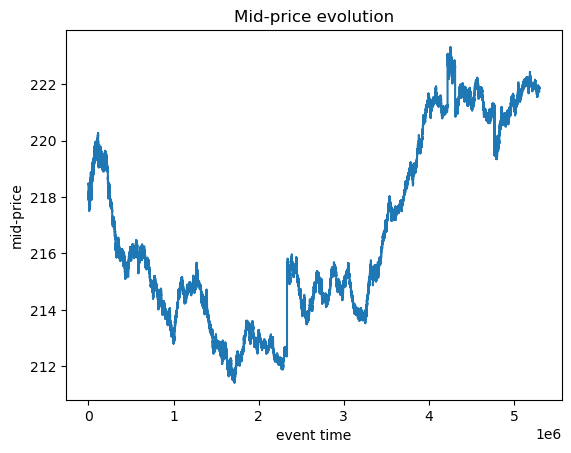

In [51]:
mid_price_evolution_emp = ((ob_file['AskPrice_1'] + ob_file['BidPrice_1'])/2)
plt.plot(mid_price_evolution_emp.to_numpy())
plt.xlabel('event time')
plt.ylabel('mid-price')
plt.title('Mid-price evolution')
plt.show()

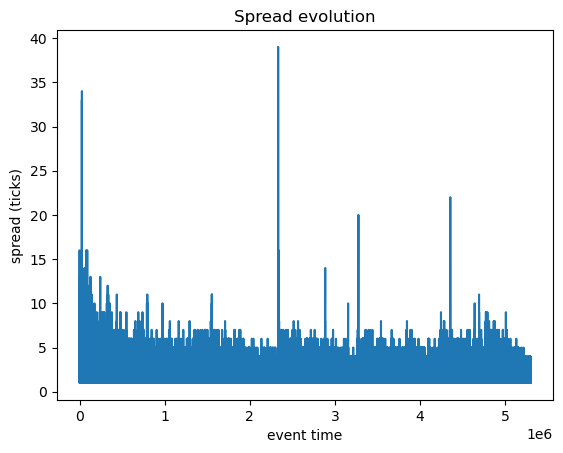

In [53]:
# Spread = melhor ask - melhor bid
spread_emp = (ob_file['AskPrice_1'] - ob_file['BidPrice_1'])/tick_size

plt.plot(spread_emp.to_numpy())
plt.xlabel('event time')
plt.ylabel('spread (ticks)')
plt.title('Spread evolution')
plt.show()


In [55]:
print('Volatility is: %.2f'%mid_price_evolution_emp.std())

Volatility is: 3.32


In [57]:
print('Events proportions:\n', message_file['Type'].value_counts(normalize = True))

Events proportions:
 Type
1    0.498489
3    0.431852
4    0.068923
2    0.000737
Name: proportion, dtype: float64
